## Librerias

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

## Datos

In [2]:
df = pd.read_csv('dfSegmentado.csv')

## Procesamiento

In [3]:
# 1. Separar características (X) y la variable objetivo (y)
# El 'Identificador' no aporta información predictiva, así que lo eliminamos.
X = df.drop(['Identificador', 'Segmento'], axis=1)
y = df['Segmento']

# 2. Codificar la variable objetivo (Segmento) a números
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
# Para recordar qué número es cada segmento
segment_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(f"Mapeo de la variable objetivo: {segment_mapping}")

Mapeo de la variable objetivo: {'A': np.int64(0), 'B': np.int64(1), 'C': np.int64(2), 'D': np.int64(3)}


In [4]:
# 3. Codificar las características (X)
# Para Graduado y Estado_Civil ('Yes'/'No') usamos un mapeo simple
X['Graduado'] = X['Graduado'].map({'No': 0, 'Yes': 1})
X['Estado_Civil'] = X['Estado_Civil'].map({'No': 0, 'Yes': 1})

# Para Puntuacion_Gasto le damos un orden
X['Puntuacion_Gasto'] = X['Puntuacion_Gasto'].map({'Low': 0, 'Average': 1, 'High': 2})

# Para Género y Profesión usamos One-Hot Encoding (pd.get_dummies)
X_encoded = pd.get_dummies(X, columns=['Genero', 'Profesion'], drop_first=True)

print("Datos preparados para el entrenamiento.")
X_encoded.head()

Datos preparados para el entrenamiento.


,Estado_Civil,Edad,Graduado,Experiencia_Laboral,Puntuacion_Gasto,Tamano_Familiar,Genero_Male,Profesion_Doctor,Profesion_Engineer,Profesion_Entertainment,Profesion_Executive,Profesion_Healthcare,Profesion_Homemaker,Profesion_Lawyer,Profesion_Marketing
0,0,22,0,1.0,0,4.0,True,False,False,False,False,True,False,False,False
1,1,38,1,1.0,1,3.0,False,False,True,False,False,False,False,False,False
2,1,67,1,1.0,0,1.0,False,False,True,False,False,False,False,False,False
3,1,67,1,0.0,2,2.0,True,False,False,False,False,False,False,True,False
4,1,40,1,1.0,2,6.0,False,False,False,True,False,False,False,False,False


## Modelo - Árbol de Decisión

In [5]:
# 1. Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)

In [6]:
# --- Modelo 1: Árbol de Decisión ---
print("--- Entrenando Árbol de Decisión ---")
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predicciones Árbol de Decisión
y_pred_dt = dt_model.predict(X_test)

--- Entrenando Árbol de Decisión ---


In [7]:
# Evaluación Árbol de Decisión
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Exactitud (Accuracy) Árbol de Decisión: {accuracy_dt:.4f}")
print("Reporte de Clasificación (Árbol de Decisión):")
print(classification_report(y_test, y_pred_dt, target_names=label_encoder.classes_))

Exactitud (Accuracy) Árbol de Decisión: 0.4250
Reporte de Clasificación (Árbol de Decisión):
              precision    recall  f1-score   support

           A       0.35      0.35      0.35       391
           B       0.30      0.34      0.32       369
           C       0.44      0.41      0.42       380
           D       0.60      0.57      0.58       474

    accuracy                           0.43      1614
   macro avg       0.42      0.42      0.42      1614
weighted avg       0.43      0.43      0.43      1614



## Modelo - Random Forest

In [8]:
print("\n--- Entrenando Random Forest ---")
# n_estimators=100 significa que usará 100 árboles
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predicciones Random Forest
y_pred_rf = rf_model.predict(X_test)


--- Entrenando Random Forest ---


In [9]:
# Evaluación Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Exactitud (Accuracy) Random Forest: {accuracy_rf:.4f}")
print("Reporte de Clasificación (Random Forest):")
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))

Exactitud (Accuracy) Random Forest: 0.4641
Reporte de Clasificación (Random Forest):
              precision    recall  f1-score   support

           A       0.36      0.35      0.36       391
           B       0.33      0.33      0.33       369
           C       0.48      0.49      0.48       380
           D       0.63      0.64      0.64       474

    accuracy                           0.46      1614
   macro avg       0.45      0.45      0.45      1614
weighted avg       0.46      0.46      0.46      1614



## Comparacion

In [10]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Decision Tree Accuracy: 0.4250309789343247
Random Forest Accuracy: 0.46406443618339527


## Importancia de las variables en el Random Forest

C:\Users\Usuario\AppData\Local\Temp\ipykernel_24504\2079120669.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_importancias, palette='viridis')


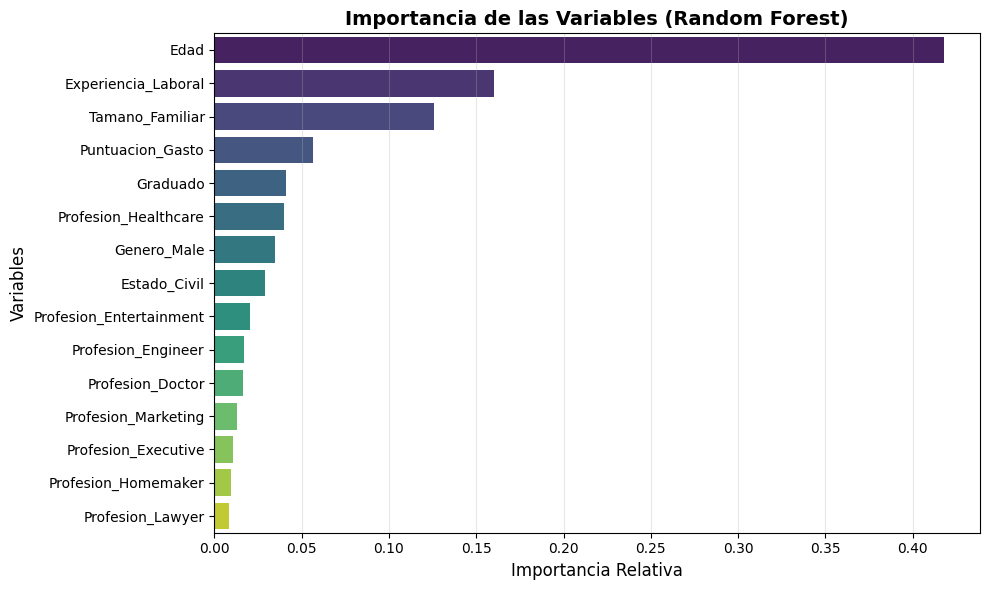

Top 5 variables más importantes:
           Variable  Importancia
               Edad     0.417697
Experiencia_Laboral     0.160007
    Tamano_Familiar     0.125904
   Puntuacion_Gasto     0.056603
           Graduado     0.040807


In [11]:
# Analizar la importancia de las variables en el Random Forest
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Obtener la importancia de las características
importancias = rf_model.feature_importances_
columnas = X_train.columns

# Crear un DataFrame para ordenar y visualizar mejor
df_importancias = pd.DataFrame({
    'Variable': columnas, 
    'Importancia': importancias
})
# Ordenar de mayor a menor importancia
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)

# Graficar
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_importancias, palette='viridis')
plt.title('Importancia de las Variables (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importancia Relativa', fontsize=12)
plt.ylabel('Variables', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Imprimir el top 5 en texto
print("Top 5 variables más importantes:")
print(df_importancias.head(5).to_string(index=False))

## Optimizacion de Random Forest

In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

print("--- Buscando los mejores hiperparámetros para Random Forest ---")
print("Esto puede tardar uno o dos minutos...")

# Definir la "cuadrícula" de parámetros a probar
param_grid = {
    'n_estimators': [100, 200],         # Cantidad de árboles
    'max_depth': [5, 10, 15, None],     # Profundidad máxima (evita sobreajuste)
    'min_samples_split': [2, 10, 20],   # Mínimo de muestras para dividir un nodo
    'min_samples_leaf': [1, 5, 10]      # Mínimo de muestras en hojas finales
}

# Inicializar un nuevo Random Forest base
rf_base = RandomForestClassifier(random_state=42)

# Configurar GridSearchCV (prueba todas las combinaciones usando validación cruzada cv=3)
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, 
                           cv=3, n_jobs=-1, verbose=1, scoring='accuracy')

# Ejecutar el entrenamiento
grid_search.fit(X_train, y_train)

# Ver resultados
print(f"\n¡Búsqueda terminada!")
print(f"Mejores parámetros encontrados:\n{grid_search.best_params_}")

# Evaluar el modelo optimizado con los datos de prueba
mejor_rf = grid_search.best_estimator_
y_pred_optimizado = mejor_rf.predict(X_test)
accuracy_opt = accuracy_score(y_test, y_pred_optimizado)

print(f"\nExactitud (Accuracy) del Random Forest Optimizado: {accuracy_opt:.4f}")

--- Buscando los mejores hiperparámetros para Random Forest ---
Esto puede tardar uno o dos minutos...
Fitting 3 folds for each of 72 candidates, totalling 216 fits

¡Búsqueda terminada!
Mejores parámetros encontrados:
{'max_depth': 15, 'min_samples_leaf': 10, 'min_samples_split': 2, 'n_estimators': 200}

Exactitud (Accuracy) del Random Forest Optimizado: 0.5186


## Matriz de confusion - Random Forest Optimizado

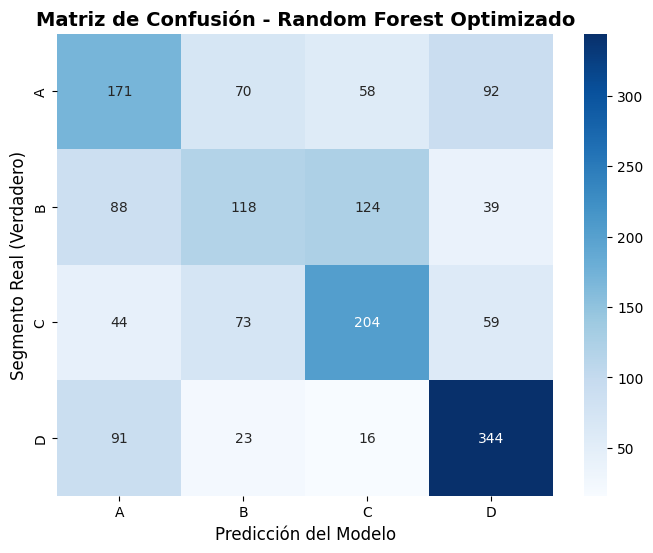

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calcular la matriz de confusión con las predicciones del modelo optimizado
cm = confusion_matrix(y_test, y_pred_optimizado)

# Crear el mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)

plt.title('Matriz de Confusión - Random Forest Optimizado', fontsize=14, fontweight='bold')
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Segmento Real (Verdadero)', fontsize=12)
plt.show()

## Conclusion 

* ¿Es posible identificar grupos diferenciados de clientes en función de su perfil y comportamiento de consumo?

Sí, es posible, pero con matices importantes. Las fronteras entre ciertos segmentos son difusas y revelan un solapamiento en el comportamiento del consumidor: 

1. El modelo reveló que la Edad (42%), la Experiencia Laboral (16%) y el Tamaño Familiar (12%) conforman casi el 70% del peso en la decisión del segmento. Esto nos indica que el comportamiento de compra de estos clientes está dictado principalmente por su etapa vital (juventud, adultez, retiro, consolidación familiar) y no tanto por su Profesión o si poseen un título universitario.

2. El Segmento D es el grupo más diferenciado y fácil de identificar para el algoritmo. Al observar los datos, este segmento concentra a la población más joven, con menor experiencia laboral y familias más grandes (o dependientes).
